# **Enviroment Setup**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    LSTM,
    Bidirectional,
    Dropout
)

print("TensorFlow Version:", tf.__version__)

2026-05-15 20:11:11.744858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778875872.258973      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778875872.364334      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778875873.403666      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778875873.403730      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778875873.403733      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00003-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00004-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00002-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00001-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00009-of-00010


In [ ]:
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/saved_data', exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


**Loading 1 file only as a test**

In [ ]:
file_path = "/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00001-of-00010"

df = pd.read_csv(
    file_path,
    sep='\t',
    nrows=5
)

df

,I think I'm goign to have to inform your posts a few times in order to gain even a small appreciation on how it all fits togethed but it looks very interesting!,I think I'm going to have to re-read your posts a few times in order to gain even a small understanding of how it all fits together but it certainly looks very interesting!
0,EverySaturday we have the King Of Club 'Drawin...,Every Saturday we have the King Of Clubs Drawing.
1,Just then background of lemonade stand was ink...,Then background of the lemonade stand was inke...
2,V-029595 Aleter Universe Lip Gloss Lapstick Qu...,V-029595 Altered Universe Lip Gloss Lipstick Q...
3,In the same floor is a staircase that access a...,On the same floor there is a staircase that gi...
4,Using It A2 Hosting Managed WP Discount Coupon...,How to use A2 Hosting Managed WP Discount Coup...


In [ ]:
file_path = "/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00001-of-00010"

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None,
    names=['incorrect', 'correct']
)

df.head()

,incorrect,correct
0,I think I'm goign to have to inform your posts...,I think I'm going to have to re-read your post...
1,EverySaturday we have the King Of Club 'Drawin...,Every Saturday we have the King Of Clubs Drawing.
2,Just then background of lemonade stand was ink...,Then background of the lemonade stand was inke...
3,V-029595 Aleter Universe Lip Gloss Lapstick Qu...,V-029595 Altered Universe Lip Gloss Lipstick Q...
4,In the same floor is a staircase that access a...,On the same floor there is a staircase that gi...


**Dataset Info**

In [ ]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Samples:")
print(df.head())



# =========================
# Remove Missing Values
# =========================

df = df.dropna()

print("\n New Shape:", df.shape)

Dataset Shape: (18377055, 2)

Missing Values:
incorrect     1
correct      91
dtype: int64

First 5 Samples:
                                           incorrect  \
0  I think I'm goign to have to inform your posts...   
1  EverySaturday we have the King Of Club 'Drawin...   
2  Just then background of lemonade stand was ink...   
3  V-029595 Aleter Universe Lip Gloss Lapstick Qu...   
4  In the same floor is a staircase that access a...   

                                             correct  
0  I think I'm going to have to re-read your post...  
1  Every Saturday we have the King Of Clubs Drawing.  
2  Then background of the lemonade stand was inke...  
3  V-029595 Altered Universe Lip Gloss Lipstick Q...  
4  On the same floor there is a staircase that gi...  

 New Shape: (18376963, 2)


**Working on 1 million samples**

In [ ]:
df_small = df.sample(
    n=1_000_000,
    random_state=42
)

df_BOW = df.sample(
    n=500_000,
    random_state=42
)


print("Sampled Dataset Shape:", df_small.shape)
print("BOW Dataset Shape:", df_BOW.shape)


save_path = "/kaggle/working/saved_data/gec_1m.csv"
BOW_save_path = "/kaggle/working/saved_data/gec_500k.csv"


df_small.to_csv(save_path, index=False)
df_BOW.to_csv(BOW_save_path, index=False)


print("Dataset saved successfully.")
print("Saved at:", save_path)

print("BOW Dataset saved successfully.")
print("Saved at:", BOW_save_path)

Sampled Dataset Shape: (1000000, 2)
BOW Dataset Shape: (500000, 2)
Dataset saved successfully.
Saved at: /kaggle/working/saved_data/gec_1m.csv
BOW Dataset saved successfully.
Saved at: /kaggle/working/saved_data/gec_500k.csv


**Basic Text Cleaning**

In [ ]:
import re

def clean_text(text):

    # convert to string
    text = str(text)

    # lowercase
    text = text.lower()

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # remove leading/trailing spaces
    text = text.strip()

    return text


# Apply cleaning
df_small['incorrect'] = df_small['incorrect'].apply(clean_text)
df_small['correct'] = df_small['correct'].apply(clean_text)


df_BOW['incorrect'] = df_BOW['incorrect'].apply(clean_text)
df_BOW['correct'] = df_BOW['correct'].apply(clean_text)



print("Text cleaning completed.")


#Check
for i in range(5):
    print("Incorrect :", df_small.iloc[i]['incorrect'])
    print("Correct   :", df_small.iloc[i]['correct'])
    print("-" * 60)


#Save
m_clean_path = "/kaggle/working/saved_data/gec_1m_cleaned.csv"
BOW_clean_path = "/kaggle/working/saved_data/gec_500k_cleaned.csv"



df_small.to_csv(m_clean_path, index=False)
df_BOW.to_csv(BOW_clean_path, index=False)



print("Cleaned dataset saved successfully.")

Text cleaning completed.
Incorrect : to snort a sticky phlegm from his nostrils.
Correct   : to snort the sticky phlegm out of his nostrils.
------------------------------------------------------------
Incorrect : this downward trend is not looking good.i was asked by a tpu wcg member if i was going to stay or return to xs and i said i would stay unless tpu commitment started to wane.
Correct   : this downward trend is not looking good.i was asked by a tpu wcg member if i was going to stay or return to xs and i said i would stay,unless tpu commitment started to wane.
------------------------------------------------------------
Incorrect : to keep your roof clean and health, visit to jim thomas maintenance!
Correct   : to keep your roof clean and healthy, visit jim thomas maintenance!
------------------------------------------------------------
Incorrect : ecommerce best practices optimizing the user experience ecommerce ux overview and best practices well-performanceing e-c sites have 

# **TASK 1 - BoW Baseline**

**Create Classification Dataset**

In [ ]:
incorrect_df = pd.DataFrame({
    'text': df_BOW['incorrect'],
    'label': 0
})

correct_df = pd.DataFrame({
    'text': df_BOW['correct'],
    'label': 1
})

# Combine both
classification_df = pd.concat(
    [incorrect_df, correct_df],
    ignore_index=True
)

print("Classification Dataset Shape:")
print(classification_df.shape)

classification_df.head()

Classification Dataset Shape:
(1000000, 2)


,text,label
0,to snort a sticky phlegm from his nostrils.,0
1,this downward trend is not looking good.i was ...,0
2,"to keep your roof clean and health, visit to j...",0
3,ecommerce best practices optimizing the user e...,0
4,on the motion of senator walsh's the debate wa...,0


**Shuffle Dataset**

In [ ]:
classification_df = classification_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

classification_df.head()

,text,label
0,is there a different formula for finding ideal...,1
1,measurements as well as inpiration pictures yo...,0
2,check out our range of oto capes to shelter yo...,1
3,"chances are, you’re like most people – thinkin...",1
4,get deal online offer expires in 3 months 51% ...,0


**Train/Test Split**

In [ ]:
X = classification_df['text']
y = classification_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 800000
Testing Samples : 200000


**Vectorizer**

In [ ]:
vectorizer = CountVectorizer(
    max_features=10000
)

#keeps only the 20,000 most frequent words to: reduce memory usage, speed up training, prevent overfitting

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print("Training Shape:", X_train_bow.shape)
print("Testing Shape :", X_test_bow.shape)

Training Shape: (800000, 10000)
Testing Shape : (200000, 10000)


**Neural Network Baseline**

In [ ]:
X_train_bow = X_train_bow.astype('float32')
X_test_bow = X_test_bow.astype('float32')

#Conversion done to be tensor freindly


#BoW Neural Network
bow_model = Sequential([

    Dense(128, activation='relu', input_shape=(10000,)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

bow_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bow_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_path = "/kaggle/working/checkpoints/bow_best_model.keras"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

**Model Training**

In [ ]:
history = bow_model.fit(
    X_train_bow,
    y_train,

    validation_split=0.1,

    epochs=3,
    batch_size=512,

    callbacks=[checkpoint_callback]
)

Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.5405 - loss: 0.6880
Epoch 1: val_accuracy improved from -inf to 0.55771, saving model to /kaggle/working/checkpoints/bow_best_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 988s 701ms/step - accuracy: 0.5405 - loss: 0.6880 - val_accuracy: 0.5577 - val_loss: 0.6822
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5700 - loss: 0.6763
Epoch 2: val_accuracy did not improve from 0.55771
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 319s 227ms/step - accuracy: 0.5700 - loss: 0.6763 - val_accuracy: 0.5550 - val_loss: 0.6832
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5795 - loss: 0.6706
Epoch 3: val_accuracy did not improve from 0.55771
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 136s 96ms/step - accuracy: 0.5795 - loss: 0.6706 - val_accuracy: 0.5462 - val_loss: 0.6865


**Model Evaluation**

In [ ]:
test_loss, test_accuracy = bow_model.evaluate(
    X_test_bow,
    y_test
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - accuracy: 0.5438 - loss: 0.6868
Test Loss     : 0.6865997910499573
Test Accuracy : 0.5463650226593018


**Generate Predictions**

In [ ]:
y_pred_probs = bow_model.predict(X_test_bow)

# Convert probabilities to binary labels
y_pred = (y_pred_probs > 0.5).astype(int) #0.5 is used as a threshold

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 66s 11ms/step


**Accuracy and F1 Score**

In [ ]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", acc)
print("F1 Score :", f1)

Accuracy : 0.546365
F1 Score : 0.5650274953135712


**Confusion Matrix**

[[50346 49653]
 [41074 58927]]


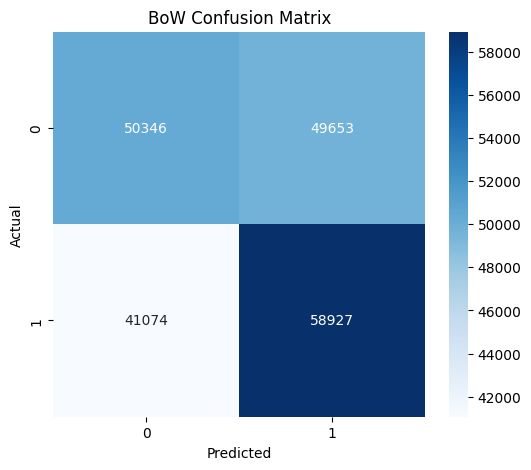

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BoW Confusion Matrix")

plt.show()

**Inspect Grammar Successes & Failures**

In [ ]:
results_df = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': y_pred.flatten()
})

# Correct predictions
correct_examples = results_df[
    results_df['actual'] == results_df['predicted']
]

# Wrong predictions
wrong_examples = results_df[
    results_df['actual'] != results_df['predicted']
]

print("========== Correct Predictions ==========\n")

for i in range(5):
    row = correct_examples.iloc[i]

    print("Sentence :", row['text'])
    print("Actual   :", row['actual'])
    print("Predicted:", row['predicted'])
    print("-" * 60)


print("\n========== Wrong Predictions ==========\n")

for i in range(5):
    row = wrong_examples.iloc[i]

    print("Sentence :", row['text'])
    print("Actual   :", row['actual'])
    print("Predicted:", row['predicted'])
    print("-" * 60)

========== Correct Predictions ==========

Sentence : i know that this type of book, short stories that are from multiple genres aren’t going to be everyone’s cup of tea, but if you enjoy stepping out of the box and reading something a bit different than pick up out through the attic by quincy j. allen. it is a great read.
Actual   : 1
Predicted: 1
------------------------------------------------------------
Sentence : registration, insurance card, if requested.
Actual   : 1
Predicted: 1
------------------------------------------------------------
Sentence : so is seen from angle, it is 10/17 for republicans an 7/17 for democrats after firefire day.
Actual   : 0
Predicted: 0
------------------------------------------------------------
Sentence : to ensure that public services are provided in an efficient and people friendly manner.
Actual   : 1
Predicted: 1
------------------------------------------------------------
Sentence : thanks for joining us for the special hop!!!
Actual   : 1


**Important Interpretation:** The Bag of Words representation (BOW) ignores word order and contextual dependencies, making it fundamentally limited for Grammar Error Correction tasks involving sentence structure and long-range grammatical relationships.

# **Task 2 - LSTM without Attention**

**Add Start and End Tokens**

In [ ]:

#df_small['correct'] = (
 #   df_small['correct']
  #  .str.replace('<start>', '', regex=False)
   # .str.replace('<end>', '', regex=False)
    #.str.strip()
#)
import pandas as pd


df_small=pd.read_csv("/kaggle/working/saved_data/gec_1m_cleaned.csv")
df_small.shape

(1000000, 2)

In [ ]:
df_small['correct'] = (
    '<start> ' +
    df_small['correct'] +
    ' <end>'
)

df_small.head()

,incorrect,correct
0,to snort a sticky phlegm from his nostrils.,<start> to snort the sticky phlegm out of his ...
1,this downward trend is not looking good.i was ...,<start> this downward trend is not looking goo...
2,"to keep your roof clean and health, visit to j...","<start> to keep your roof clean and healthy, v..."
3,ecommerce best practices optimizing the user e...,<start> ecommerce best practices optimizing th...
4,on the motion of senator walsh's the debate wa...,<start> on the motion of senator walsh the deb...


In [ ]:
df_small.head()

,incorrect,correct
0,to snort a sticky phlegm from his nostrils.,<start> to snort the sticky phlegm out of his ...
1,this downward trend is not looking good.i was ...,<start> this downward trend is not looking goo...
2,"to keep your roof clean and health, visit to j...","<start> to keep your roof clean and healthy, v..."
3,ecommerce best practices optimizing the user e...,<start> ecommerce best practices optimizing th...
4,on the motion of senator walsh's the debate wa...,<start> on the motion of senator walsh the deb...


**Input and Output Text**

In [ ]:
input_texts = df_small['incorrect'].tolist()
target_texts = df_small['correct'].tolist()

print("Number of Input Sentences :", len(input_texts))
print("Number of Target Sentences:", len(target_texts))

Number of Input Sentences : 1000000
Number of Target Sentences: 1000000


**Tokenizer**: builds the vocabulary and converts words into integer IDs.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 30000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    input_texts + target_texts
)

print("Tokenizer created successfully.")
print("Vocabulary Size:", VOCAB_SIZE)

Tokenizer created successfully.
Vocabulary Size: 30000


In [ ]:
import pickle

tokenizer_path = "/kaggle/working/checkpoints/tokenizer.pkl"

with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


**Convert Text to Sequences**

In [ ]:
input_sequences = tokenizer.texts_to_sequences(input_texts)
target_sequences = tokenizer.texts_to_sequences(target_texts)

print("Example Input Sequence:")
print(input_sequences[0])

print("\nExample Target Sequence:")
print(target_sequences[0])

Example Input Sequence:
[4, 1, 8, 8188, 1, 24, 52, 1]

Example Target Sequence:
[7, 4, 1, 2, 8188, 1, 55, 5, 52, 1, 6]


**Maximum Sequence Length** as neural networks require fixed-length input tensors. Therefore, we have to determine the longest sequences before applying sequence padding.

In [ ]:
max_input_len = max(
    len(seq) for seq in input_sequences
)

max_target_len = max(
    len(seq) for seq in target_sequences
)

print("Max Input Length :", max_input_len)
print("Max Target Length:", max_target_len)

Max Input Length : 5378
Max Target Length: 189


which is not realiable; Therefore, we should: remove extremely long samples and keep only realistic sentence lengths.

**Remove extremely long senctences**

In [ ]:
MAX_LEN = 50

filtered_input_sequences = []
filtered_target_sequences = []

for inp, tgt in zip(input_sequences, target_sequences):

    if len(inp) <= MAX_LEN and len(tgt) <= MAX_LEN:

        filtered_input_sequences.append(inp)
        filtered_target_sequences.append(tgt)

print("Remaining Samples:", len(filtered_input_sequences))

input_sequences = filtered_input_sequences
target_sequences = filtered_target_sequences

max_input_len = max(len(seq) for seq in input_sequences)
max_target_len = max(len(seq) for seq in target_sequences)

print("Max Input Length :", max_input_len)
print("Max Target Length:", max_target_len)

Remaining Samples: 932972
Max Input Length : 50
Max Target Length: 50


**Pad Sequences**

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_input_len,
    padding='post'
)

decoder_input_data = pad_sequences(
    target_sequences,
    maxlen=max_target_len,
    padding='post'
)

print("Encoder Input Shape:", encoder_input_data.shape)
print("Decoder Input Shape:", decoder_input_data.shape)

Encoder Input Shape: (932972, 50)
Decoder Input Shape: (932972, 50)


**Decoder Target Data Generation**

In [ ]:
decoder_target_data = np.zeros_like(decoder_input_data)

decoder_target_data[:, :-1] = decoder_input_data[:, 1:]

print("Decoder Target Shape:")
print(decoder_target_data.shape)

Decoder Target Shape:
(932972, 50)


**Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

(
    encoder_train,
    encoder_test,

    decoder_input_train,
    decoder_input_test,

    decoder_target_train,
    decoder_target_test

) = train_test_split(

    encoder_input_data,
    decoder_input_data,
    decoder_target_data,

    test_size=0.2,
    random_state=42
)

print("Encoder Train Shape:", encoder_train.shape)
print("Encoder Test Shape :", encoder_test.shape)

Encoder Train Shape: (746377, 50)
Encoder Test Shape : (186595, 50)


**Convert to NumPy Arrays**

In [ ]:
encoder_train = np.array(encoder_train)
encoder_test = np.array(encoder_test)

decoder_input_train = np.array(decoder_input_train)
decoder_input_test = np.array(decoder_input_test)

decoder_target_train = np.array(decoder_target_train)
decoder_target_test = np.array(decoder_target_test)

print("Conversion completed.")

Conversion completed.


**Expand Decoder Targets**

In [ ]:
decoder_target_train = np.expand_dims(
    decoder_target_train,
    -1
)

decoder_target_test = np.expand_dims(
    decoder_target_test,
    -1
)

print("Decoder Target Shape:")
print(decoder_target_train.shape)

Decoder Target Shape:
(746377, 50, 1)


**Define Hyperparameters**

In [ ]:
VOCAB_SIZE = 30000

EMBEDDING_DIM = 256

LSTM_UNITS = 256

BATCH_SIZE = 128

EPOCHS = 5

**Build Encoder**

In [ ]:
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Embedding,
    Dense
)

from tensorflow.keras.models import Model

# Encoder input
encoder_inputs = Input(shape=(max_input_len,))

# Embedding layer
encoder_embedding = Embedding(
    VOCAB_SIZE,
    EMBEDDING_DIM
)(encoder_inputs)

# Encoder LSTM
encoder_lstm = LSTM(
    LSTM_UNITS,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_embedding
)

encoder_states = [state_h, state_c]

**Build Decoder**

In [ ]:
decoder_inputs = Input(shape=(max_target_len,))

decoder_embedding = Embedding(
    VOCAB_SIZE,
    EMBEDDING_DIM
)(decoder_inputs)

decoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

decoder_dense = Dense(
    VOCAB_SIZE,
    activation='softmax'
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

**Full Seq2Seq Model**

In [ ]:
seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

seq2seq_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 256)   │  7,680,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 256)   │  7,680,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    525,312 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 50, 256), │    525,312 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 30000) │  7,710,000 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,120,624 (92.01 MB)

 Trainable params: 24,120,624 (92.01 MB)

 Non-trainable params: 0 (0.00 B)

**Checkpoint Saving**

In [ ]:
checkpoint_path = "/kaggle/working/checkpoints/lstm_seq2seq.keras"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**LSTM Model Training**

In [ ]:
history = seq2seq_model.fit(

    [encoder_train, decoder_input_train],
    decoder_target_train,

    validation_split=0.1,

    batch_size=BATCH_SIZE,
    epochs=EPOCHS,

    callbacks=[
        checkpoint_callback,
        early_stop
    ]
)

Epoch 1/5


I0000 00:00:1778880320.470405     225 cuda_dnn.cc:529] Loaded cuDNN version 91002


5248/5248 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.6484 - loss: 2.7962
Epoch 1: val_accuracy improved from -inf to 0.69186, saving model to /kaggle/working/checkpoints/lstm_seq2seq.keras
5248/5248 ━━━━━━━━━━━━━━━━━━━━ 2028s 385ms/step - accuracy: 0.6484 - loss: 2.7962 - val_accuracy: 0.6919 - val_loss: 2.1190
Epoch 2/5
5248/5248 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.6996 - loss: 2.0150
Epoch 2: val_accuracy improved from 0.69186 to 0.71440, saving model to /kaggle/working/checkpoints/lstm_seq2seq.keras
5248/5248 ━━━━━━━━━━━━━━━━━━━━ 2031s 387ms/step - accuracy: 0.6996 - loss: 2.0150 - val_accuracy: 0.7144 - val_loss: 1.8340
Epoch 3/5
5248/5248 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7215 - loss: 1.7404
Epoch 3: val_accuracy improved from 0.71440 to 0.73092, saving model to /kaggle/working/checkpoints/lstm_seq2seq.keras
5248/5248 ━━━━━━━━━━━━━━━━━━━━ 2030s 387ms/step - accuracy: 0.7215 - loss: 1.7403 - val_accuracy: 0.7309 - val_loss: 1.6633
Epoch 4/5
5248/52

**Inference Model**

In [ ]:
# =========================
# Encoder Inference Model
# =========================

encoder_model = Model(
    encoder_inputs,
    encoder_states
)
# =========================
# Decoder Inference Model
# =========================

# Decoder state inputs
decoder_state_input_h = Input(shape=(LSTM_UNITS,))
decoder_state_input_c = Input(shape=(LSTM_UNITS,))

decoder_states_inputs = [
    decoder_state_input_h,
    decoder_state_input_c
]

# Decoder embedding
decoder_embedding2 = Embedding(
    VOCAB_SIZE,
    EMBEDDING_DIM
)(decoder_inputs)

# Decoder LSTM
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    decoder_embedding2,
    initial_state=decoder_states_inputs
)

decoder_states2 = [state_h2, state_c2]

# Dense output
decoder_outputs2 = decoder_dense(
    decoder_outputs2
)

# Final decoder model
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,

    [decoder_outputs2] + decoder_states2
)


# =========================
# Reverse Token Mapping
# =========================

reverse_word_index = {
    index: word
    for word, index in tokenizer.word_index.items()
}

print("Reverse dictionary created.")


# =========================
# Decode Sequence Function
# =========================

def decode_sequence(input_seq):

    # Encode input sentence
    states_value = encoder_model.predict(
        input_seq,
        verbose=0
    )

    # Start token
    target_seq = np.zeros((1, 1))

    target_seq[0, 0] = tokenizer.word_index['start']

    stop_condition = False

    decoded_sentence = ''

    while not stop_condition:

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0
        )

        # Highest probability token
        sampled_token_index = np.argmax(
            output_tokens[0, -1, :]
        )

        sampled_word = reverse_word_index.get(
            sampled_token_index,
            ''
        )

        # Stop conditions
        if (
            sampled_word == 'end'
            or len(decoded_sentence.split()) > max_target_len
        ):
            stop_condition = True

        else:
            decoded_sentence += ' ' + sampled_word

        # Update target sequence
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence

Reverse dictionary created.


**Test Grammar Correction**

In [ ]:
for i in range(5):

    input_seq = encoder_test[i:i+1]

    predicted_sentence = decode_sequence(
        input_seq
    )

    original_input = input_texts[i]

    original_target = target_texts[i]

    print("Incorrect Sentence:")
    print(original_input)

    print("\nActual Correction:")
    print(original_target)

    print("\nPredicted Correction:")
    print(predicted_sentence)

    print("\n" + "="*80 + "\n")

Incorrect Sentence:
to snort a sticky phlegm from his nostrils.

Actual Correction:
<start> to snort the sticky phlegm out of his nostrils. <end>

Predicted Correction:
 worth for per per in is is is


Incorrect Sentence:
this downward trend is not looking good.i was asked by a tpu wcg member if i was going to stay or return to xs and i said i would stay unless tpu commitment started to wane.

Actual Correction:
<start> this downward trend is not looking good.i was asked by a tpu wcg member if i was going to stay or return to xs and i said i would stay,unless tpu commitment started to wane. <end>

Predicted Correction:
 also also also our our our from and and and and and and and and


Incorrect Sentence:
to keep your roof clean and health, visit to jim thomas maintenance!

Actual Correction:
<start> to keep your roof clean and healthy, visit jim thomas maintenance! <end>

Predicted Correction:
 the is is also who for for in and and and and and and and service service service and and an

# **Task 3 - LSTM with Attention**

In [ ]:
from tensorflow.keras.layers import Attention

# =========================
# Hyperparameters
# =========================

VOCAB_SIZE = 30000

EMBEDDING_DIM = 256

LSTM_UNITS = 256

BATCH_SIZE = 125

EPOCHS = 5

**Encoder**: Now encoder must return FULL sequences.

In [ ]:
encoder_inputs = Input(
    shape=(max_input_len,)
)

encoder_embedding = Embedding(
    VOCAB_SIZE,
    EMBEDDING_DIM
)(encoder_inputs)

encoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_embedding
)

encoder_states = [state_h, state_c]

**Decoder**

In [ ]:
decoder_inputs = Input(
    shape=(max_target_len,)
)

decoder_embedding = Embedding(
    VOCAB_SIZE,
    EMBEDDING_DIM
)(decoder_inputs)

decoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

**Attention Layer**

In [ ]:
attention_layer = Attention()

attention_output = attention_layer(
    [decoder_outputs, encoder_outputs]
)

# =========================
# Concatenate Attention = Attention + Decoder
# =========================

from tensorflow.keras.layers import Concatenate

decoder_combined_context = Concatenate(
    axis=-1
)(
    [decoder_outputs, attention_output]
)

**Final Output Layer**

In [ ]:
decoder_dense = Dense(
    VOCAB_SIZE,
    activation='softmax'
)

decoder_final_output = decoder_dense(
    decoder_combined_context
)

**Build Attention Model**

In [ ]:
attention_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_final_output
)

attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

attention_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 50, 256)   │  7,680,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 50, 256)   │  7,680,000 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 50, 256), │    525,312 │ embedding_3[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 50, 256), │    525,312 │ embedding_4[0][0… │
│                     │ (None, 256),      │            │ lstm_2[0][1],     │
│                     │ (None, 256)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 50, 256)   │          0 │ lstm_3[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 50, 512)   │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 30000) │ 15,390,000 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,800,624 (121.31 MB)

 Trainable params: 31,800,624 (121.31 MB)

 Non-trainable params: 0 (0.00 B)

**Checkpoint Saving**

In [ ]:
checkpoint_path = "/kaggle/working/checkpoints/attention_model.keras"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**Attention Model Training**

In [ ]:
history_attention = attention_model.fit(

    [encoder_train, decoder_input_train],
    decoder_target_train,

    validation_split=0.1,

    batch_size=BATCH_SIZE,
    epochs=EPOCHS,

    callbacks=[
        checkpoint_callback,
        early_stop
    ]
)

Epoch 1/5
5374/5374 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7209 - loss: 2.2496
Epoch 1: val_accuracy improved from -inf to 0.90949, saving model to /kaggle/working/checkpoints/attention_model.keras
5374/5374 ━━━━━━━━━━━━━━━━━━━━ 3182s 592ms/step - accuracy: 0.7209 - loss: 2.2494 - val_accuracy: 0.9095 - val_loss: 0.7140
Epoch 2/5
5374/5374 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9176 - loss: 0.6290
Epoch 2: val_accuracy improved from 0.90949 to 0.92320, saving model to /kaggle/working/checkpoints/attention_model.keras
5374/5374 ━━━━━━━━━━━━━━━━━━━━ 3209s 597ms/step - accuracy: 0.9176 - loss: 0.6290 - val_accuracy: 0.9232 - val_loss: 0.5643
Epoch 3/5
5374/5374 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9281 - loss: 0.5051
Epoch 3: val_accuracy improved from 0.92320 to 0.92470, saving model to /kaggle/working/checkpoints/attention_model.keras
5374/5374 ━━━━━━━━━━━━━━━━━━━━ 3223s 600ms/step - accuracy: 0.9281 - loss: 0.5051 - val_accuracy: 0.9247 - val_loss: 0.536

**Plot Training Curves**

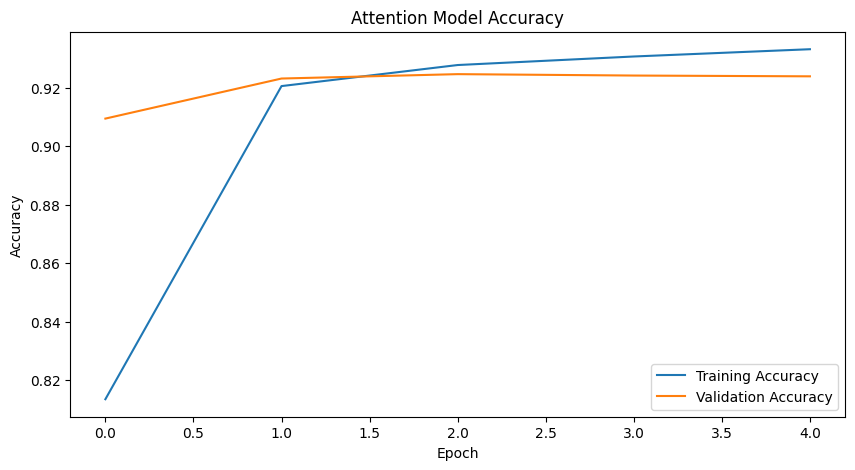

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    history_attention.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_attention.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Attention Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

**Plot Loss Curves**

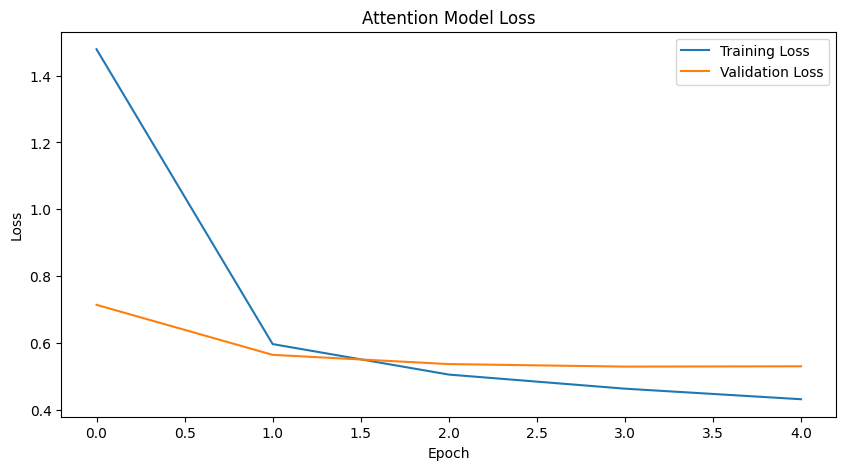

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_attention.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_attention.history['val_loss'],
    label='Validation Loss'
)

plt.title('Attention Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

**Attention Inference Pipeline**

In [ ]:
# =========================
# Encoder Inference Model
# =========================

encoder_model_attention = Model(
    encoder_inputs,
    [encoder_outputs, state_h, state_c]
)

# =========================
# Decoder Inputs
# =========================

decoder_state_input_h = Input(
    shape=(LSTM_UNITS,)
)

decoder_state_input_c = Input(
    shape=(LSTM_UNITS,)
)

decoder_hidden_state_input = Input(
    shape=(max_input_len, LSTM_UNITS)
)

# =========================
# Decoder Embedding
# =========================

decoder_inputs_single = Input(shape=(1,))

decoder_embedding2 = Embedding(
    VOCAB_SIZE,
    EMBEDDING_DIM
)(decoder_inputs_single)

# =========================
# Decoder LSTM
# =========================

decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    decoder_embedding2,

    initial_state=[
        decoder_state_input_h,
        decoder_state_input_c
    ]
)

# =========================
# Attention Layer
# =========================

attention_output2 = attention_layer(
    [decoder_outputs2, decoder_hidden_state_input]
)

# =========================
# Combine Attention Context
# =========================

decoder_combined_context2 = Concatenate(
    axis=-1
)(
    [decoder_outputs2, attention_output2]
)

# =========================
# Final Decoder Output
# =========================

decoder_outputs2 = decoder_dense(
    decoder_combined_context2
)

**Decoder Inference Model Building**

In [ ]:
decoder_model_attention = Model(

    [
        decoder_inputs_single,
        decoder_hidden_state_input,
        decoder_state_input_h,
        decoder_state_input_c
    ],

    [
        decoder_outputs2,
        state_h2,
        state_c2
    ]
)

**Reverse Dictionary**

In [ ]:
reverse_word_index = {
    index: word
    for word, index in tokenizer.word_index.items()
}

**Attention Decode Function**

In [ ]:
def decode_sequence_attention(input_seq):

    # Encode input
    encoder_outs, state_h, state_c = (
        encoder_model_attention.predict(
            input_seq,
            verbose=0
        )
    )

    # Start token
    target_seq = np.zeros((1, 1))

    target_seq[0, 0] = tokenizer.word_index['start']

    decoded_sentence = ''

    stop_condition = False

    while not stop_condition:

        output_tokens, h, c = (
            decoder_model_attention.predict(
                [
                    target_seq,
                    encoder_outs,
                    state_h,
                    state_c
                ],
                verbose=0
            )
        )

        sampled_token_index = np.argmax(
            output_tokens[0, -1, :]
        )

        sampled_word = reverse_word_index.get(
            sampled_token_index,
            ''
        )

        # Stop condition
        if (
            sampled_word == 'end'
            or len(decoded_sentence.split()) > max_target_len
        ):
            stop_condition = True

        else:
            decoded_sentence += ' ' + sampled_word

        # Update target token
        target_seq = np.zeros((1, 1))

        target_seq[0, 0] = sampled_token_index

        # Update states
        state_h, state_c = h, c

    return decoded_sentence

**Generate Attention Corrections**

In [ ]:
for i in range(5):

    input_seq = encoder_test[i:i+1]

    predicted_sentence = decode_sequence_attention(
        input_seq
    )

    print("Incorrect Sentence:")
    print(input_texts[i])

    print("\nActual Correction:")
    print(target_texts[i])

    print("\nPredicted Correction:")
    print(predicted_sentence)

    print("\n" + "="*80 + "\n")

Incorrect Sentence:
to snort a sticky phlegm from his nostrils.

Actual Correction:
<start> to snort the sticky phlegm out of his nostrils. <end>

Predicted Correction:
 spending one per per per project project


Incorrect Sentence:
this downward trend is not looking good.i was asked by a tpu wcg member if i was going to stay or return to xs and i said i would stay unless tpu commitment started to wane.

Actual Correction:
<start> this downward trend is not looking good.i was asked by a tpu wcg member if i was going to stay or return to xs and i said i would stay,unless tpu commitment started to wane. <end>

Predicted Correction:
 we also <OOV> from <OOV> <OOV> <OOV> <OOV> <OOV>


Incorrect Sentence:
to keep your roof clean and health, visit to jim thomas maintenance!

Actual Correction:
<start> to keep your roof clean and healthy, visit jim thomas maintenance! <end>

Predicted Correction:
 the the is which which which which and and and and and and and


Incorrect Sentence:
ecommerce b

# **Task 4 - Transformer**

In [ ]:
from tensorflow.keras.layers import (
    MultiHeadAttention,
    LayerNormalization,
    Dropout,
    Dense,
    Embedding,
    Input
)

from tensorflow.keras.models import Model

# =========================
# Hyperparameters
# =========================

VOCAB_SIZE = 30000

EMBEDDING_DIM = 256

NUM_HEADS = 8

FF_DIM = 256

BATCH_SIZE = 128

EPOCHS = 5

**Positional Encoding Layer**

In [ ]:
class PositionalEmbedding(tf.keras.layers.Layer):

    def __init__(
        self,
        sequence_length,
        vocab_size,
        embed_dim
    ):
        super().__init__()

        self.token_embeddings = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )

        self.position_embeddings = Embedding(
            input_dim=sequence_length,
            output_dim=embed_dim
        )

        self.sequence_length = sequence_length

    def call(self, inputs):

        length = tf.shape(inputs)[-1]

        positions = tf.range(
            start=0,
            limit=length,
            delta=1
        )

        embedded_tokens = self.token_embeddings(inputs)

        embedded_positions = self.position_embeddings(
            positions
        )

        return embedded_tokens + embedded_positions

**Encoder Block**

In [ ]:
class TransformerEncoder(tf.keras.layers.Layer):

    def __init__(
        self,
        embed_dim,
        dense_dim,
        num_heads
    ):
        super().__init__()

        self.attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.dense_proj = tf.keras.Sequential([
            Dense(dense_dim, activation='relu'),
            Dense(embed_dim)
        ])

        self.layernorm_1 = LayerNormalization()

        self.layernorm_2 = LayerNormalization()

    def call(self, inputs):

        attention_output = self.attention(
            inputs,
            inputs
        )

        proj_input = self.layernorm_1(
            inputs + attention_output
        )

        proj_output = self.dense_proj(
            proj_input
        )

        return self.layernorm_2(
            proj_input + proj_output
        )

**Transformer Model Building**

In [ ]:
encoder_inputs = Input(
    shape=(max_input_len,)
)

x = PositionalEmbedding(
    max_input_len,
    VOCAB_SIZE,
    EMBEDDING_DIM
)(encoder_inputs)

x = TransformerEncoder(
    EMBEDDING_DIM,
    FF_DIM,
    NUM_HEADS
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    VOCAB_SIZE,
    activation='softmax'
)(x)

transformer_model = Model(
    encoder_inputs,
    outputs
)

transformer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transformer_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 50, 256)        │     7,692,800 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 50, 256)        │     2,236,160 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50, 30000)      │     7,710,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,638,960 (67.29 MB)

 Trainable params: 17,638,960 (67.29 MB)

 Non-trainable params: 0 (0.00 B)

**Prepare Transformer Targets**

In [ ]:
transformer_targets = decoder_target_data.squeeze()

transformer_targets = transformer_targets[
    :, :max_input_len
]

print(transformer_targets.shape)

(932972, 50)


**Checkpoint Saving**

In [ ]:
checkpoint_path = "/kaggle/working/checkpoints/transformer_model.keras"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**Transformer Training**

In [ ]:
history_transformer = transformer_model.fit(

    encoder_input_data,
    transformer_targets,

    validation_split=0.1,

    batch_size=BATCH_SIZE,
    epochs=EPOCHS,

    callbacks=[
        checkpoint_callback,
        early_stop
    ]
)

Epoch 1/5


I0000 00:00:1778906576.440154     226 service.cc:152] XLA service 0x7be07dbb4bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778906576.440255     226 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778906576.440267     226 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778906589.181251     226 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6560/6560 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.7579 - loss: 1.7094
Epoch 1: val_accuracy improved from -inf to 0.78012, saving model to /kaggle/working/checkpoints/transformer_model.keras
6560/6560 ━━━━━━━━━━━━━━━━━━━━ 1405s 212ms/step - accuracy: 0.7579 - loss: 1.7093 - val_accuracy: 0.7801 - val_loss: 1.0732
Epoch 2/5
6560/6560 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7732 - loss: 1.1008
Epoch 2: val_accuracy improved from 0.78012 to 0.78080, saving model to /kaggle/working/checkpoints/transformer_model.keras
6560/6560 ━━━━━━━━━━━━━━━━━━━━ 1369s 209ms/step - accuracy: 0.7732 - loss: 1.1008 - val_accuracy: 0.7808 - val_loss: 1.0428
Epoch 3/5
6560/6560 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7752 - loss: 1.0514
Epoch 3: val_accuracy improved from 0.78080 to 0.78197, saving model to /kaggle/working/checkpoints/transformer_model.keras
6560/6560 ━━━━━━━━━━━━━━━━━━━━ 1370s 209ms/step - accuracy: 0.7752 - loss: 1.0514 - val_accuracy: 0.7820 - val_loss: 1.0272
Ep

# **Task 5 - Transformer - Pretrained T5**

In [ ]:
!pip install transformers sentencepiece accelerate -q

PyTorch HuggingFace support is: more stable andfaster.

In [ ]:
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration
)

import torch
import pandas as pd
import numpy as np

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print(device)

cuda


**Load Model**

In [ ]:
tokenizer_t5 = T5Tokenizer.from_pretrained(
    't5-small'
)

t5_model = T5ForConditionalGeneration.from_pretrained(
    't5-small'
)

t5_model = t5_model.to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

**Create Smaller Fine-Tuning Dataset**

In [ ]:
df_t5 = df_small.sample(
    100000,
    random_state=42
)

df_t5 = df_t5.reset_index(drop=True)

print(df_t5.shape)

(100000, 2)


**Prepare Input Text**

In [ ]:
inputs = [
    "grammar: " + text
    for text in df_t5['incorrect']
]

targets = list(df_t5['correct'])

**Tokenize Inputs**

In [ ]:
MAX_LEN = 64

input_encodings = tokenizer_t5(
    inputs,

    padding='max_length',
    truncation=True,

    max_length=MAX_LEN,

    return_tensors='pt'
)

target_encodings = tokenizer_t5(
    targets,

    padding='max_length',
    truncation=True,

    max_length=MAX_LEN,

    return_tensors='pt'
)

**Create PyTorch Dataset**

In [ ]:
# =========================
# Create PyTorch Dataset
# =========================

class GrammarDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        input_encodings,
        target_encodings
    ):

        self.input_encodings = input_encodings

        self.target_encodings = target_encodings

    def __len__(self):

        return len(
            self.input_encodings['input_ids']
        )

    def __getitem__(self, idx):

        item = {
            'input_ids':
                self.input_encodings[
                    'input_ids'
                ][idx],

            'attention_mask':
                self.input_encodings[
                    'attention_mask'
                ][idx],

            'labels':
                self.target_encodings[
                    'input_ids'
                ][idx]
        }

        return item

**Build Dataset + DataLoader**

In [ ]:
train_dataset = GrammarDataset(
    input_encodings,
    target_encodings
)

train_loader = torch.utils.data.DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True
)

**Optimizer**

In [ ]:
optimizer = torch.optim.AdamW(
    t5_model.parameters(),
    lr=3e-5
)

**Fine-Tune T5**

In [ ]:
EPOCHS = 3

t5_model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch[
            'input_ids'
        ].to(device)

        attention_mask = batch[
            'attention_mask'
        ].to(device)

        labels = batch[
            'labels'
        ].to(device)

        outputs = t5_model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} Loss: {avg_loss:.4f}"
    )

Epoch 1 Loss: 0.4464
Epoch 2 Loss: 0.3670
Epoch 3 Loss: 0.3528


**Save Fine-Tuned Model**

In [ ]:
save_path = "/kaggle/working/t5_grammar_model"

t5_model.save_pretrained(save_path)

tokenizer_t5.save_pretrained(save_path)

print("Model Saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved


**Grammar Correction Function**

In [ ]:
def correct_grammar_t5(sentence):

    input_text = "grammar: " + sentence

    input_ids = tokenizer_t5.encode(

        input_text,

        return_tensors='pt',

        max_length=64,

        truncation=True
    ).to(device)

    outputs = t5_model.generate(

        input_ids,

        max_length=64,

        num_beams=5,

        early_stopping=True
    )

    corrected_sentence = tokenizer_t5.decode(

        outputs[0],

        skip_special_tokens=True
    )

    return corrected_sentence

**Test T5 Corrections**

In [ ]:
for i in range(5):

    incorrect = df_t5['incorrect'][i]

    actual = df_t5['correct'][i]

    prediction = correct_grammar_t5(
        incorrect
    )

    print("Incorrect Sentence:")
    print(incorrect)

    print("\nActual Correction:")
    print(actual)

    print("\nPredicted Correction:")
    print(prediction)

    print("\n" + "="*80 + "\n")

Incorrect Sentence:
personal social media account information - that will be used within the application api - to manage post content in your behalf.

Actual Correction:
personal social media account information that will be used within the application api to manage post content on your behalf.

Predicted Correction:
personal social media account information - that will be used within the application api to manage content on your behalf.


Incorrect Sentence:
measurements as well as inpiration pictures you’d like to share between us.

Actual Correction:
measurements, as well as any inspiration pictures you’d like to share with us.

Predicted Correction:
measurements as well as inpiration pictures you’d like to share with us.


Incorrect Sentence:
t-thank you for the awesome giveaway!! absoly-love your warmers!

Actual Correction:
thanks for the awesome giveaway!! absolutely love your warmers!

Predicted Correction:
t-thank you for the awesome giveaway!! i love your warmers!


Incorrect

# **Task 6 - FINAL EVALUATION & COMPARISON**

**Plot LSTM Curves**

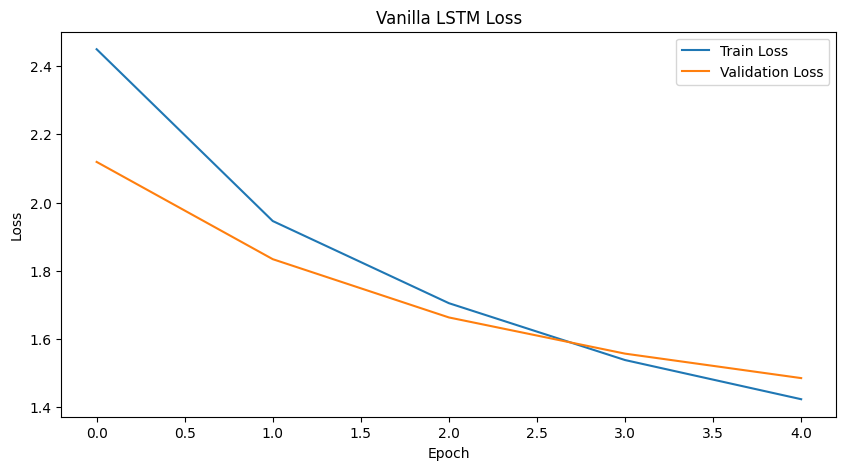

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Vanilla LSTM Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

**Plot Attention Curves**

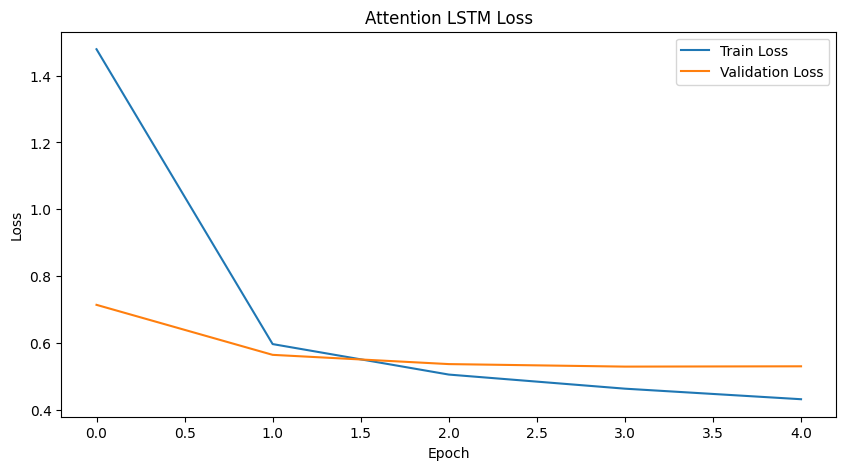

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history_attention.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_attention.history['val_loss'],
    label='Validation Loss'
)

plt.title('Attention LSTM Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()